SNA Task: Erdős-Rényi vs. Small-World on 50 nodes.

[Step 1] Generating and visualizing example data...


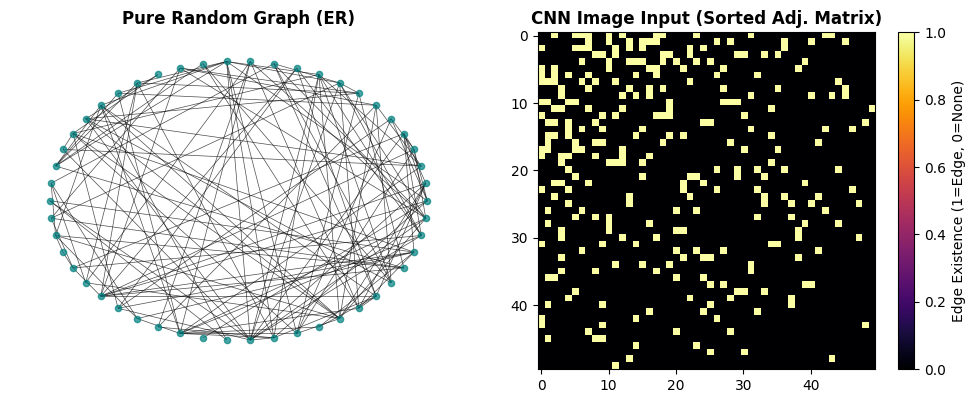

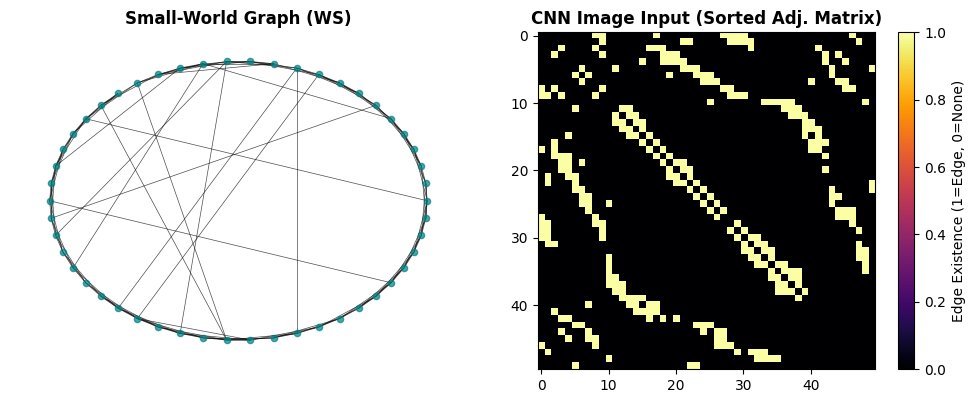


[Step 2] Building dataset of 1000 matrix images...

[Step 3] Building and training the CNN on 800 samples...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9281 - loss: 0.2171 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 6.1587e-04
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 9.0379e-04 - val_accuracy: 1.0000 - val_loss: 2.0812e-04
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.0062e-04 - val_accuracy: 1.0000 - val_loss: 5.6786e-05
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 1.9234e-04 - val_accuracy: 1.0000 - val_loss: 2.1965e-05
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 4.6041e-04 - val_accuracy: 1.0000 - val_loss: 1.3713e-05
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.5121e-05 - val_accuracy: 1.0000 - val_loss: 4.7682e-06
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 4.0645e

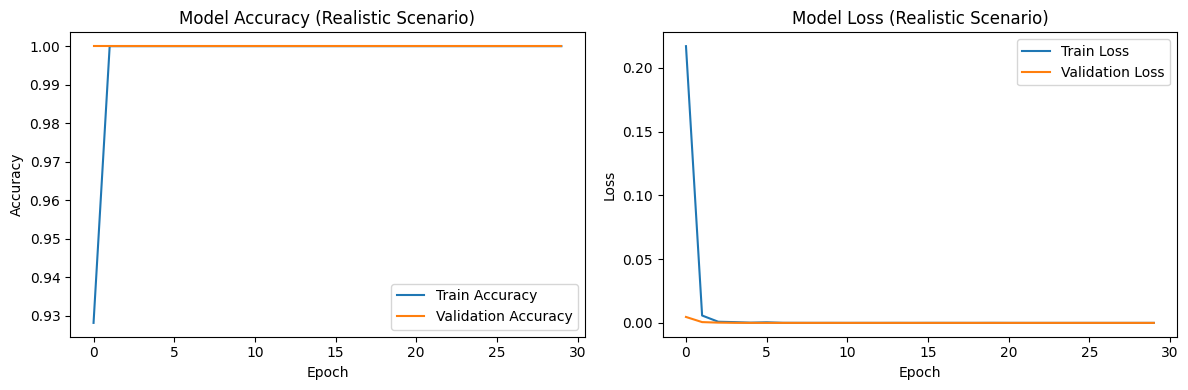

In [ ]:
import numpy as np
import networkx as nx
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from matplotlib import cm

# ==========================================
# 0. CONFIGURATION & CORE SETTINGS
# ==========================================
# Setting a seed makes the results (and harder difficulty) reproducible.
np.random.seed(42)
tf.random.set_seed(42)

# We must lock the node count so ALL graphs generate fixed-size images without padding artifacts.
NUM_NODES = 50  # This makes 50x50 matrix "images"
NUM_GRAPHS = 1000 # Increased dataset size as the task is harder.

print(f"SNA Task: Erdős-Rényi vs. Small-World on {NUM_NODES} nodes.")

# ==========================================
# 1. VISUALIZATION FUNCTION (Pre-processing Show & Tell)
# ==========================================
def visualize_graph_conversion(class_label):
    """Generates an example graph, converts it to matrix, and plots both."""
    G = generate_graph_by_type(class_label)
    title_graph = "Pure Random Graph (ER)" if class_label == 0 else "Small-World Graph (WS)"

    # 1. Plot the Graph (Topology)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    # Using a circular layout often helps see Small-World 'lattice' residues
    pos = nx.circular_layout(G)
    nx.draw(G, pos, with_labels=False, node_size=20, node_color='teal', edge_color='black', width=0.5, alpha=0.7)
    plt.title(title_graph, fontweight='bold')

    # 2. Convert and Plot the Sorted Matrix (CNN Input Image)
    # Perform the canonical sort by degree (Still necessary, but doesn't solve the problem now)
    node_degrees = dict(G.degree())
    sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)
    adj_matrix = nx.to_numpy_array(G, nodelist=sorted_nodes)

    plt.subplot(1, 2, 2)
    # Use 'nearest' to clearly see the edges, 'inferno' provides high contrast
    plt.imshow(adj_matrix, cmap='inferno', interpolation='nearest')
    plt.title("CNN Image Input (Sorted Adj. Matrix)", fontweight='bold')
    plt.colorbar(label='Edge Existence (1=Edge, 0=None)')
    plt.tight_layout()
    plt.show()


# ==========================================
# 2. DATASET GENERATION
# ==========================================
print("\n[Step 1] Generating and visualizing example data...")

def generate_graph_by_type(label):
    """
    Generates complex graphs. Ensuring they are connected makes the problem robust.
    Adjusting params keeps average degree (~6) and edge count similar between classes.
    """
    connected = False
    G = None
    while not connected:
        if label == 0:
            # Class 0: Erdős-Rényi (Pure Random). p=0.12 gives average degree ~6.
            G = nx.fast_gnp_random_graph(NUM_NODES, p=0.12)
        else:
            # Class 1: Watts-Strogatz (Small-World). k=6 (6 neighbors), p=0.1 rewiring.
            # WS graphs are almost always connected.
            G = nx.watts_strogatz_graph(n=NUM_NODES, k=6, p=0.1)
        # Check connectivity
        if label == 1 or nx.is_connected(G):
             connected = True
    return G

# --- Visualize Examples of our Graph/Image mappings ---
visualize_graph_conversion(0) # Class 0 Example
visualize_graph_conversion(1) # Class 1 Example


# ==========================================
# 3. PREPROCESSING LOOP (BUILD DATASET)
# ==========================================
print(f"\n[Step 2] Building dataset of {NUM_GRAPHS} matrix images...")

def preprocess_graph_to_image(G):
    """Method 1: Graph to sorted adjacency matrix."""
    node_degrees = dict(G.degree())
    sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)
    adj_matrix = nx.to_numpy_array(G, nodelist=sorted_nodes)
    return adj_matrix

# Build the dataset
X_data = []
y_labels = []

# Class balance is handled automatically by i % 2
for i in range(NUM_GRAPHS):
    label = i % 2
    G = generate_graph_by_type(label)
    img_matrix = preprocess_graph_to_image(G)

    X_data.append(img_matrix)
    y_labels.append(label)

# Convert and add the Channel dimension (N, 50, 50, 1)
X = np.array(X_data)[..., np.newaxis]
y = np.array(y_labels)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# 4. CNN DESIGN AND TRAINING (Updated for Difficulty)
# ==========================================
print(f"\n[Step 3] Building and training the CNN on {X_train.shape[0]} samples...")

model = models.Sequential([
    # Input is 50x50x1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(NUM_NODES, NUM_NODES, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second convolution to find deeper patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flattening and deeper classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), # Increased dropout as small datasets overfit easily
    layers.Dense(1, activation='sigmoid') # Binary classification
])

# Changed optimizer to RMSprop - sometimes better than Adam for difficult, noisy data.
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train for longer epochs as the task is harder.
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)


# ==========================================
# 5. EVALUATE & ANALYZE PERFORMANCE
# ==========================================
print("\n[Step 4] Final Evaluation...")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy (Realistic): {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nClassification Report (Erdős-Rényi vs Small-World):")
print(classification_report(y_test, y_pred, target_names=['Pure Random (0)', 'Small-World (1)']))


# ==========================================
# 6. TRAINING HISTORY VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy (Realistic Scenario)')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss (Realistic Scenario)')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

SNA Task: Erdős-Rényi vs. Small-World on 50 nodes.

[Step 1] Generating and visualizing example data...


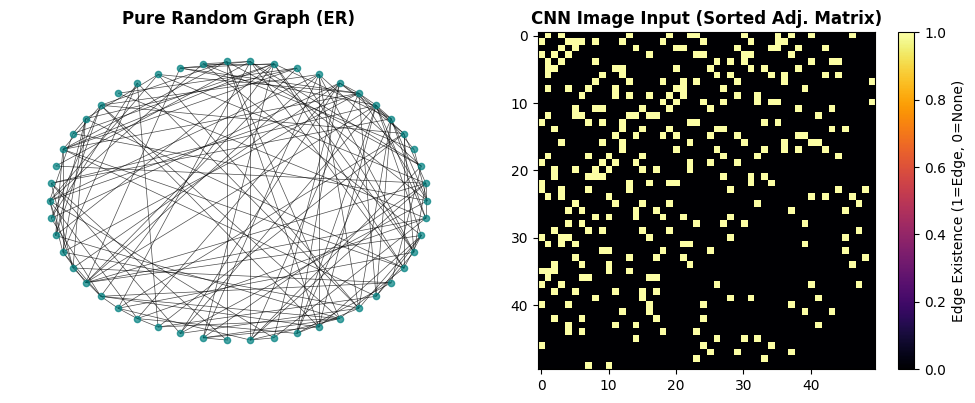

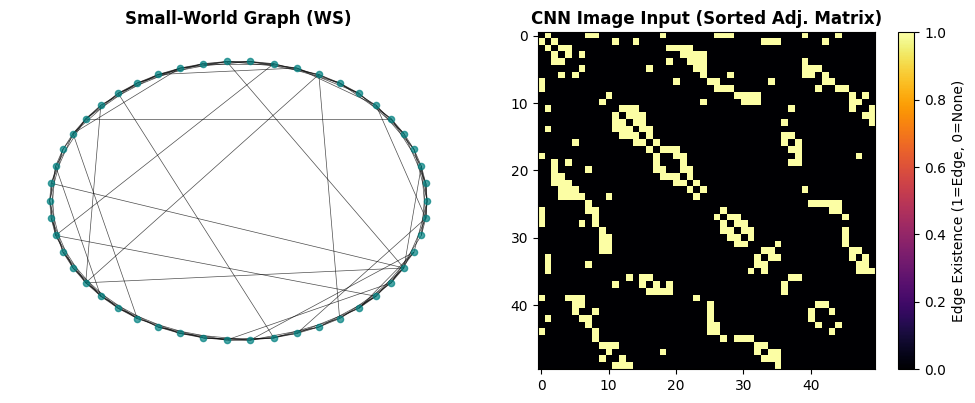


[Step 2] Building dataset of 1000 matrix images...

[Step 3] Building and training the CNN on 800 samples...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9219 - loss: 0.2506 - val_accuracy: 0.9937 - val_loss: 0.0200
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9937 - loss: 0.0199 - val_accuracy: 0.9062 - val_loss: 0.2283
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9891 - loss: 0.0267 - val_accuracy: 0.9937 - val_loss: 0.0064
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9953 - loss: 0.0084 - val_accuracy: 0.9625 - val_loss: 0.0944
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9953 - loss: 0.0112 - val_accuracy: 0.9937 - val_loss: 0.0070
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 5.1415


Final Test Accuracy (Realistic): 1.0000
Final Test Loss: 0.0011

Classification Report (Erdős-Rényi vs Small-World):
                 precision    recall  f1-score   support

Pure Random (0)       1.00      1.00      1.00        97
Small-World (1)       1.00      1.00      1.00       103

       accuracy                           1.00       200
      macro avg       1.00      1.00      1.00       200
   weighted avg       1.00      1.00      1.00       200



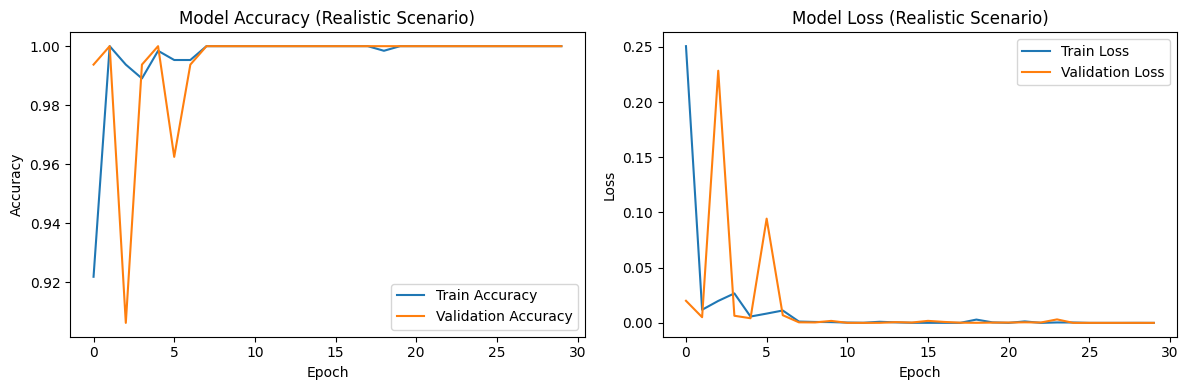

In [ ]:
import numpy as np
import networkx as nx
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from matplotlib import cm

np.random.seed(42)
tf.random.set_seed(42)

NUM_NODES = 50  

NUM_GRAPHS = 1000 

print(f"SNA Task: Erdős-Rényi vs. Small-World on {NUM_NODES} nodes.")

def visualize_graph_conversion(class_label):
    """Generates an example graph, converts it to matrix, and plots both."""
    G = generate_graph_by_type(class_label)
    title_graph = "Pure Random Graph (ER)" if class_label == 0 else "Small-World Graph (WS)"

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)

    pos = nx.circular_layout(G)
    nx.draw(G, pos, with_labels=False, node_size=20, node_color='teal', edge_color='black', width=0.5, alpha=0.7)
    plt.title(title_graph, fontweight='bold')

    node_degrees = dict(G.degree())
    sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)
    adj_matrix = nx.to_numpy_array(G, nodelist=sorted_nodes)

    plt.subplot(1, 2, 2)

    plt.imshow(adj_matrix, cmap='inferno', interpolation='nearest')
    plt.title("CNN Image Input (Sorted Adj. Matrix)", fontweight='bold')
    plt.colorbar(label='Edge Existence (1=Edge, 0=None)')
    plt.tight_layout()
    plt.show()

print("\n[Step 1] Generating and visualizing example data...")

def generate_graph_by_type(label):
    """
    Generates complex graphs. Ensuring they are connected makes the problem robust.
    Adjusting params keeps average degree (~6) and edge count similar between classes.
    """
    connected = False
    G = None
    while not connected:
        if label == 0:

            G = nx.fast_gnp_random_graph(NUM_NODES, p=0.12)
        else:

            G = nx.watts_strogatz_graph(n=NUM_NODES, k=6, p=0.1)

        if label == 1 or nx.is_connected(G):
             connected = True
    return G

visualize_graph_conversion(0) 

visualize_graph_conversion(1) 

print(f"\n[Step 2] Building dataset of {NUM_GRAPHS} matrix images...")

def preprocess_graph_to_image(G):
    """
    Method 1 (Revised): Converts a graph to a Spectrally Ordered adjacency matrix.
    This groups communities together and prevents the CNN from cheating
    using degree distributions.
    """

    try:

        sorted_nodes = list(nx.spectral_ordering(G))
    except nx.NetworkXError:

        start_node = list(G.nodes())[0]
        bfs_edges = list(nx.bfs_edges(G, source=start_node))
        sorted_nodes = [start_node] + [v for u, v in bfs_edges]

        missing_nodes = set(G.nodes()) - set(sorted_nodes)
        sorted_nodes.extend(list(missing_nodes))

    adj_matrix = nx.to_numpy_array(G, nodelist=sorted_nodes)

    return adj_matrix

X_data = []
y_labels = []

for i in range(NUM_GRAPHS):
    label = i % 2
    G = generate_graph_by_type(label)
    img_matrix = preprocess_graph_to_image(G)

    X_data.append(img_matrix)
    y_labels.append(label)

X = np.array(X_data)[..., np.newaxis]
y = np.array(y_labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n[Step 3] Building and training the CNN on {X_train.shape[0]} samples...")

model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(NUM_NODES, NUM_NODES, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), 

    layers.Dense(1, activation='sigmoid') 

])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

print("\n[Step 4] Final Evaluation...")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy (Realistic): {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nClassification Report (Erdős-Rényi vs Small-World):")
print(classification_report(y_test, y_pred, target_names=['Pure Random (0)', 'Small-World (1)']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy (Realistic Scenario)')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='lower right')

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss (Realistic Scenario)')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()